In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# **Exploratory Data Analysis - Predict Diagnosis**

In [ ]:
# Read the CSV file
train_file = '/content/top_atlas_biome.csv'
top_atlas_biome = pd.read_csv(train_file)

In [ ]:
top_atlas_biome.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Columns: 123 entries, Unnamed: 0 to Veillonella sp CAG 933
dtypes: float64(120), int64(3)
memory usage: 3.2 MB


In [ ]:
top_atlas_biome.shape

(3387, 123)

In [ ]:
top_atlas_biome.head()

,Unnamed: 0,External ID,diagnosis,Flavonifractor plautii,Odoribacter laneus,Prevotella jejuni,Bacteroidetes oral taxon 274,Bacteroides sp CAG 144,Alistipes indistinctus,Haemophilus pittmaniae,...,Actinomyces turicensis,Bacteroides fragilis,Dielma fastidiosa,Collinsella aerofaciens,Megamonas hypermegale,Actinomyces sp ICM47,Campylobacter showae,Dysgonomonas mossii,Proteus hauseri,Veillonella sp CAG 933
0,0,0,0,-0.059459,-0.118588,-0.02179,-0.017185,-0.113847,-0.278715,-0.102956,...,-0.030334,-0.257121,-0.178618,-0.28472,-0.100584,-0.017185,-0.02523,-0.079374,-0.093336,-0.098301
1,1,10,0,0.328646,-0.118588,-0.02179,-0.017185,-0.113847,-0.278715,-0.102956,...,-0.030334,1.816247,-0.178618,-0.28472,-0.100584,-0.017185,-0.02523,-0.079374,-0.093336,-0.098301
2,2,34,0,-0.051080,-0.118588,-0.02179,-0.017185,-0.113847,-0.278715,-0.102956,...,-0.030334,-0.338548,-0.178618,-0.28472,-0.100584,-0.017185,-0.02523,-0.079374,-0.093336,-0.098301
3,3,78,0,0.808663,-0.118588,-0.02179,-0.017185,-0.113847,-0.278715,-0.102956,...,-0.030334,-0.164399,-0.178618,-0.28472,-0.100584,-0.017185,-0.02523,-0.079374,-0.093336,-0.098301
4,4,120,0,0.140433,-0.118588,-0.02179,-0.017185,-0.113847,-0.278715,-0.102956,...,-0.030334,-0.057903,-0.178618,-0.28472,-0.100584,-0.017185,-0.02523,-0.079374,-0.093336,-0.098301


In [ ]:
top_atlas_biome.drop(['Unnamed: 0'], axis=1, inplace=True)

In [ ]:
top_atlas_biome.describe()

,External ID,diagnosis,Flavonifractor plautii,Odoribacter laneus,Prevotella jejuni,Bacteroidetes oral taxon 274,Bacteroides sp CAG 144,Alistipes indistinctus,Haemophilus pittmaniae,Prevotella corporis,...,Actinomyces turicensis,Bacteroides fragilis,Dielma fastidiosa,Collinsella aerofaciens,Megamonas hypermegale,Actinomyces sp ICM47,Campylobacter showae,Dysgonomonas mossii,Proteus hauseri,Veillonella sp CAG 933
count,3387.000000,3387.000000,3.387000e+03,3.387000e+03,3.387000e+03,3.387000e+03,3.387000e+03,3.387000e+03,3.387000e+03,3.387000e+03,...,3.387000e+03,3.387000e+03,3.387000e+03,3.387000e+03,3.387000e+03,3.387000e+03,3.387000e+03,3.387000e+03,3.387000e+03,3.387000e+03
mean,689.317095,0.794804,1.101373e-17,-2.097853e-18,7.342485e-17,1.783175e-17,6.083773e-17,-1.678282e-17,5.873988e-17,2.936994e-17,...,1.048926e-17,8.391411e-18,-1.153819e-17,4.090813e-17,2.936994e-17,3.041887e-17,3.671242e-17,7.342485e-17,7.552270e-17,-1.048926e-17
std,395.519679,0.838104,1.000148e+00,1.000148e+00,1.000148e+00,1.000148e+00,1.000148e+00,1.000148e+00,1.000148e+00,1.000148e+00,...,1.000148e+00,1.000148e+00,1.000148e+00,1.000148e+00,1.000148e+00,1.000148e+00,1.000148e+00,1.000148e+00,1.000148e+00,1.000148e+00
min,0.000000,0.000000,-4.231503e-01,-1.185877e-01,-2.179009e-02,-1.718528e-02,-1.138473e-01,-2.787153e-01,-1.029559e-01,-8.902571e-02,...,-3.033438e-02,-3.672412e-01,-1.786181e-01,-2.847200e-01,-1.005835e-01,-1.718528e-02,-2.522994e-02,-7.937379e-02,-9.333594e-02,-9.830126e-02
25%,351.000000,0.000000,-4.070667e-01,-1.185877e-01,-2.179009e-02,-1.718528e-02,-1.138473e-01,-2.787153e-01,-1.029559e-01,-8.902571e-02,...,-3.033438e-02,-3.672412e-01,-1.786181e-01,-2.847200e-01,-1.005835e-01,-1.718528e-02,-2.522994e-02,-7.937379e-02,-9.333594e-02,-9.830126e-02
50%,680.000000,1.000000,-3.055900e-01,-1.185877e-01,-2.179009e-02,-1.718528e-02,-1.138473e-01,-2.787153e-01,-1.029559e-01,-8.902571e-02,...,-3.033438e-02,-3.672412e-01,-1.786181e-01,-2.735687e-01,-1.005835e-01,-1.718528e-02,-2.522994e-02,-7.937379e-02,-9.333594e-02,-9.830126e-02
75%,1038.500000,2.000000,1.170471e-02,-1.185877e-01,-2.179009e-02,-1.718528e-02,-1.138473e-01,-2.787153e-01,-1.029559e-01,-8.902571e-02,...,-3.033438e-02,-1.643989e-01,-1.786181e-01,-1.244163e-01,-1.005835e-01,-1.718528e-02,-2.522994e-02,-7.937379e-02,-9.333594e-02,-9.830126e-02
max,1372.000000,2.000000,1.525748e+01,1.355681e+01,5.511656e+01,5.818935e+01,2.203555e+01,1.074157e+01,1.346480e+01,2.225256e+01,...,5.620588e+01,1.037468e+01,3.707932e+01,1.330747e+01,1.758628e+01,5.818935e+01,4.107575e+01,2.441240e+01,2.062872e+01,2.551918e+01


In [ ]:
# 0 = Crohns Disease
# 1 = Ulcerative Colitis
# 2 = Healthy
top_atlas_biome['diagnosis'].value_counts()

,count
diagnosis,
0,1608
2,913
1,866


In [ ]:
top_atlas_biome['External ID'].nunique()

1373

# **Model Creation - Predict Diagnosis**

### **Train/ Test Split - Diagnosis**

In [2]:
from sklearn.model_selection import train_test_split

In [ ]:
# Separate features (X) and target (y)
X = top_atlas_biome.drop('diagnosis', axis=1)
y = top_atlas_biome['diagnosis']

In [ ]:
# Split the data into training (80%) and validation (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nDistribution of target variable in training set:")
display(y_train.value_counts())

print("\nDistribution of target variable in validation set:")
display(y_test.value_counts())

Shape of X_train: (2709, 121)
Shape of X_test: (678, 121)
Shape of y_train: (2709,)
Shape of y_test: (678,)

Distribution of target variable in training set:


,count
diagnosis,
0,1286
2,730
1,693



Distribution of target variable in validation set:


,count
diagnosis,
0,322
2,183
1,173


### **Random Forest Classifier - Diagnosis**

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from datetime import datetime

In [ ]:
# rfc = GridSearchCV(estimator=RandomForestClassifier(), cv=3,
#              param_grid={'n_estimators':[60, 100, 120], 'max_features': [2, 5, 7],
#                          'max_depth':[3,7,10], 'class_weight':['balanced'],
#                          'criterion':('gini', 'entropy', 'log_loss')})

In [ ]:
rfc = RandomForestClassifier()

In [ ]:
start=datetime.now()
cv_scores_rfc = cross_val_score(rfc, X_train, y_train, cv=5)
end=datetime.now()
print(end-start)
print("Cross-validation scores:", cv_scores_rfc)
print("Average CV score:", cv_scores_rfc.mean())

0:00:06.914296
Cross-validation scores: [0.96494465 0.97416974 0.9704797  0.98523985 0.97597043]
Average CV score: 0.9741608746956232


### **Deep Neural Network - Diagnosis**

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import RMSprop

In [ ]:
#2 layers and 100 neurons total
def create_dnn_2_100():
    dnn_2_100 = Sequential([
        Dense(90, activation='relu'),
        Dense(3, activation='softmax') # 3 classes
    ])
    dnn_2_100.compile(optimizer=RMSprop(), loss='sparse_categorical_crossentropy', metrics=['accuracy']) # Changed loss to sparse_categorical_crossentropy
    return dnn_2_100

In [5]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

In [ ]:
# Set up K-Fold Cross-Validation
k = 5  # Number of folds
kf = KFold(n_splits=k, shuffle=True, random_state=42)

In [ ]:
accuracy_per_fold = []

# K-Fold Cross-Validation
for fold, (train_index, val_index) in enumerate(kf.split(X_train)):
    print(f'Fold {fold + 1}')

    # Split the data into training and validation sets for this fold
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # Create a new instance of the model for each fold
    dnn_2_100 = create_dnn_2_100()

    # Train the model on the training fold
    start=datetime.now()
    dnn_2_100.fit(X_train_fold, y_train_fold, epochs=20, batch_size=32, verbose=0)
    end=datetime.now()
    print(end-start)

    # Evaluate the model on the validation fold
    val_predictions = np.argmax(dnn_2_100.predict(X_val_fold), axis=1)
    accuracy = accuracy_score(y_val_fold, val_predictions)

    # Store the accuracy for this fold
    accuracy_per_fold.append(accuracy)
    print(f'Accuracy for fold {fold + 1}: {accuracy * 100:.2f}%')

Fold 1
0:00:02.695063
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Accuracy for fold 1: 47.05%
Fold 2
0:00:02.772760
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Accuracy for fold 2: 68.82%
Fold 3
0:00:04.147162
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Accuracy for fold 3: 73.62%
Fold 4
0:00:02.717018
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Accuracy for fold 4: 55.35%
Fold 5
0:00:02.605836
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Accuracy for fold 5: 55.45%


In [ ]:
# Calculate the average accuracy across all folds
average_accuracy = np.mean(accuracy_per_fold)
print(f'\nAverage Accuracy Training for model_2_100 Across {k} Folds: {average_accuracy * 100:.2f}%')


Average Accuracy Training for model_2_100 Across 5 Folds: 60.06%


# **Evaluation Metrics and Goodness of Fit - Predict Diagnosis**

In [6]:
from sklearn.metrics import classification_report

Random Forest Classifier - Diagnosis Classification Report

In [ ]:
start=datetime.now()
rfc.fit(X_train, y_train)
end=datetime.now()
print(end-start)

0:00:00.733128


In [ ]:
#Predict on the training set
y_pred_train_rfc = rfc.predict(X_train)

#Predict on the test set
y_pred_test_rfc = rfc.predict(X_test)

In [ ]:
# Training Set RFC
print('Diagnosis Classification Report Training Set RFC:')
print(classification_report(y_train, y_pred_train_rfc, zero_division=0))

Training Set RFC:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1286
           1       1.00      1.00      1.00       693
           2       1.00      1.00      1.00       730

    accuracy                           1.00      2709
   macro avg       1.00      1.00      1.00      2709
weighted avg       1.00      1.00      1.00      2709



In [ ]:
# Test Set RFC
print('Diagnosis Classification Report Test Set RFC:')
print(classification_report(y_test, y_pred_test_rfc, zero_division=0))

Test Set RFC:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       322
           1       1.00      0.96      0.98       173
           2       1.00      0.98      0.99       183

    accuracy                           0.98       678
   macro avg       0.99      0.98      0.98       678
weighted avg       0.98      0.98      0.98       678



Deep Neural Network - Diagnosis Classification Report

In [ ]:
start=datetime.now()
dnn_2_100.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1)
end=datetime.now()
print(end-start)

In [ ]:
#Predict on the training set
#y_pred_train_dnn = dnn_2_100.predict(X_train).flatten()
y_pred_train_dnn = np.argmax(dnn_2_100.predict(X_train), axis=1)

#Predict on the test set
#y_pred_test_dnn = dnn_2_100.predict(X_test).flatten()
y_pred_test_dnn = np.argmax(dnn_2_100.predict(X_test), axis=1)

In [ ]:
# Training Set DNN
print('Diagnosis Classification Report Training Set DNN:')
print(classification_report(y_train, y_pred_train_dnn, zero_division=0))

Training Set DNN:
              precision    recall  f1-score   support

           0       0.95      0.71      0.82      1286
           1       0.57      0.97      0.72       693
           2       0.94      0.74      0.83       730

    accuracy                           0.79      2709
   macro avg       0.82      0.81      0.79      2709
weighted avg       0.85      0.79      0.80      2709



In [ ]:
# Test Set DNN
print('Diagnosis Classification Report Test Set DNN:')
print(classification_report(y_test, y_pred_test_dnn, zero_division=0))

Test Set DNN:
              precision    recall  f1-score   support

           0       0.94      0.68      0.79       322
           1       0.56      0.96      0.71       173
           2       0.90      0.73      0.81       183

    accuracy                           0.76       678
   macro avg       0.80      0.79      0.77       678
weighted avg       0.83      0.76      0.77       678



### **Confusion Matrix - Predict Diagnosis**

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

RFC Model

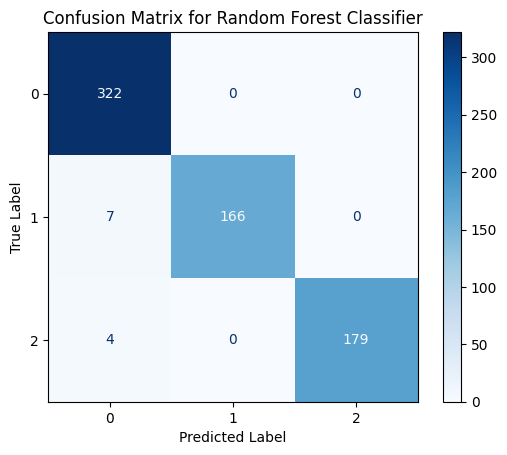

In [ ]:
# Confusion Matrix for RFC
cm_rfc = confusion_matrix(y_test, y_pred_test_rfc)
disp_rfc = ConfusionMatrixDisplay(confusion_matrix=cm_rfc, display_labels=[0, 1, 2]) # Assuming labels 0, 1, 2

disp_rfc.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Random Forest Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

DNN model

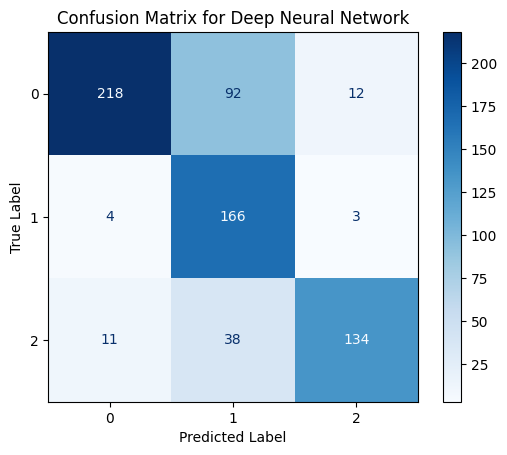

In [ ]:
# Confusion Matrix for DNN
cm_dnn = confusion_matrix(y_test, y_pred_test_dnn)
disp_dnn = ConfusionMatrixDisplay(confusion_matrix=cm_dnn, display_labels=[0, 1, 2]) # Assuming labels 0, 1, 2

disp_dnn.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Deep Neural Network')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# **EDA - Predict Inflammation Score > 150**

In [8]:
# Read the CSV file
train_file = '/content/top_atlas_fecalcal.csv'
top_atlas_fecalcal = pd.read_csv(train_file)

In [9]:
top_atlas_fecalcal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1360 entries, 0 to 1359
Data columns (total 84 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Unnamed: 0                                1360 non-null   int64  
 1   External ID                               1360 non-null   int64  
 2   fecalcal                                  1360 non-null   float64
 3   fecalcal_gt_150                           1360 non-null   int64  
 4   diagnosis                                 1360 non-null   int64  
 5   Blautia sp CAG 257                        1360 non-null   float64
 6   Turicibacter sanguinis                    1360 non-null   float64
 7   Arthrospira platensis                     1360 non-null   float64
 8   Clostridium methylpentosum                1360 non-null   float64
 9   Parvimonas sp KA00067                     1360 non-null   float64
 10  Sutterella parvirubra               

In [10]:
top_atlas_fecalcal.shape

(1360, 84)

In [ ]:
top_atlas_fecalcal.head()

,Unnamed: 0,External ID,fecalcal,fecalcal_gt_150,diagnosis,Blautia sp CAG 257,Turicibacter sanguinis,Arthrospira platensis,Clostridium methylpentosum,Parvimonas sp KA00067,...,Bacteroidales bacterium KA00251,Roseburia sp CAG 471,Leuconostoc garlicum,Lactobacillus delbrueckii,Prevotella sp CAG 1185,Klebsiella aerogenes,Enterococcus faecium,Parabacteroides johnsonii,Parvimonas micra,Acinetobacter ursingii
0,0,0,193.89000,1,0,0.938446,-0.046348,-0.024307,-0.017458,-0.03845,...,-0.03845,-0.081652,-0.025621,-0.024813,-0.040662,-0.037651,-0.075668,-0.19534,-0.035066,-0.017185
1,1,10,61.34000,0,0,-0.107113,-0.046348,-0.024307,-0.017458,-0.03845,...,-0.03845,-0.081652,-0.025621,-0.024813,-0.040662,-0.037651,-0.075668,-0.19534,-0.035066,-0.017185
2,2,31,115.27000,0,0,13.630289,-0.030060,-0.024307,-0.017458,-0.03845,...,-0.03845,-0.057566,-0.025621,-0.024813,-0.040662,-0.037651,-0.075668,-0.19534,-0.035066,-0.017185
3,3,52,23.20350,0,0,-0.008179,-0.046348,-0.024307,-0.017458,-0.03845,...,-0.03845,-0.081652,-0.025621,-0.024813,-0.040662,-0.037651,-0.075668,-0.19534,-0.035066,-0.017185
4,4,68,37.17836,0,0,1.196154,-0.046348,-0.024307,-0.017458,-0.03845,...,-0.03845,-0.052567,-0.025621,-0.024813,-0.040662,-0.037651,-0.075668,-0.19534,-0.035066,-0.017185


In [11]:
top_atlas_fecalcal.drop(['Unnamed: 0', 'diagnosis', 'fecalcal', 'External ID'], axis=1, inplace=True)

In [12]:
top_atlas_fecalcal.shape

(1360, 80)

In [13]:
top_atlas_fecalcal.describe()

,fecalcal_gt_150,Blautia sp CAG 257,Turicibacter sanguinis,Arthrospira platensis,Clostridium methylpentosum,Parvimonas sp KA00067,Sutterella parvirubra,Clostridium botulinum,Veillonella parvula,Clostridium sporogenes,...,Bacteroidales bacterium KA00251,Roseburia sp CAG 471,Leuconostoc garlicum,Lactobacillus delbrueckii,Prevotella sp CAG 1185,Klebsiella aerogenes,Enterococcus faecium,Parabacteroides johnsonii,Parvimonas micra,Acinetobacter ursingii
count,1360.000000,1360.000000,1360.000000,1360.000000,1360.000000,1360.000000,1360.000000,1360.000000,1360.000000,1360.000000,...,1360.000000,1360.000000,1360.000000,1360.000000,1360.000000,1360.000000,1360.000000,1360.000000,1360.000000,1360.000000
mean,0.350735,0.003889,0.054973,0.036229,0.025339,0.057308,0.091188,0.057308,0.085373,0.057308,...,0.057308,-0.005150,0.006287,0.020945,0.019630,0.034449,0.047699,0.063111,0.026512,0.025614
std,0.477376,1.263561,1.573560,1.577998,1.578304,1.576953,1.366199,1.576953,1.309927,1.576953,...,1.576953,0.948165,1.176692,1.550548,1.310859,1.537445,1.417828,1.195641,1.523457,1.578346
min,0.000000,-0.107113,-0.046348,-0.024307,-0.017458,-0.038450,-0.179298,-0.038450,-0.161944,-0.038450,...,-0.038450,-0.081652,-0.025621,-0.024813,-0.040662,-0.037651,-0.075668,-0.195340,-0.035066,-0.017185
25%,0.000000,-0.107113,-0.046348,-0.024307,-0.017458,-0.038450,-0.179298,-0.038450,-0.161944,-0.038450,...,-0.038450,-0.081652,-0.025621,-0.024813,-0.040662,-0.037651,-0.075668,-0.195340,-0.035066,-0.017185
50%,0.000000,-0.107113,-0.046348,-0.024307,-0.017458,-0.038450,-0.179298,-0.038450,-0.161944,-0.038450,...,-0.038450,-0.081652,-0.025621,-0.024813,-0.040662,-0.037651,-0.075668,-0.195340,-0.035066,-0.017185
75%,1.000000,-0.107113,-0.046348,-0.024307,-0.017458,-0.038450,-0.179298,-0.038450,-0.151600,-0.038450,...,-0.038450,-0.081652,-0.025621,-0.024813,-0.040662,-0.037651,-0.075668,-0.195340,-0.035066,-0.017185
max,1.000000,39.378099,38.807819,41.140005,58.187504,26.007691,16.915176,26.007691,12.638970,26.007691,...,26.007691,31.997136,43.368630,56.915113,32.960219,53.124211,18.576832,11.824064,39.693493,58.189346


In [14]:
# 0 = False
# 1 = True
top_atlas_fecalcal['fecalcal_gt_150'].value_counts()

,count
fecalcal_gt_150,
0,883
1,477


# **Model Creation - Predict Inflammation Score > 150**

### **Train/ Test Split**

In [15]:
# Separate features (X) and target (y)
X = top_atlas_fecalcal.drop('fecalcal_gt_150', axis=1)
y = top_atlas_fecalcal['fecalcal_gt_150']

In [16]:
# Split the data into training (80%) and validation (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nDistribution of target variable in training set:")
display(y_train.value_counts())

print("\nDistribution of target variable in validation set:")
display(y_test.value_counts())

Shape of X_train: (1088, 79)
Shape of X_test: (272, 79)
Shape of y_train: (1088,)
Shape of y_test: (272,)

Distribution of target variable in training set:


,count
fecalcal_gt_150,
0,706
1,382



Distribution of target variable in validation set:


,count
fecalcal_gt_150,
0,177
1,95


### **Random Forest Classifier - Predict Inflammation**

In [17]:
rfc = RandomForestClassifier()

In [18]:
start=datetime.now()
cv_scores_rfc = cross_val_score(rfc, X_train, y_train, cv=5)
end=datetime.now()
print(end-start)
print("Cross-validation scores:", cv_scores_rfc)
print("Average CV score:", cv_scores_rfc.mean())

0:00:01.428782
Cross-validation scores: [0.97706422 0.93577982 0.95412844 0.94470046 0.92626728]
Average CV score: 0.9475880437999409


### **DNN - Predict Inflammation**

In [33]:
#2 layers and 100 neurons total
def create_dnn_2_100():
    dnn_2_100 = Sequential([
        Dense(90, activation='relu'),
        Dense(2, activation='softmax') # 2 classes
    ])
    dnn_2_100.compile(optimizer=RMSprop(), loss='sparse_categorical_crossentropy', metrics=['accuracy']) # Changed loss to sparse_categorical_crossentropy
    return dnn_2_100

In [34]:
# Set up K-Fold Cross-Validation
k = 5  # Number of folds
kf = KFold(n_splits=k, shuffle=True, random_state=42)

In [35]:
accuracy_per_fold = []

# K-Fold Cross-Validation
for fold, (train_index, val_index) in enumerate(kf.split(X_train)):
    print(f'Fold {fold + 1}')

    # Split the data into training and validation sets for this fold
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # Create a new instance of the model for each fold
    dnn_2_100 = create_dnn_2_100()

    # Train the model on the training fold
    start=datetime.now()
    dnn_2_100.fit(X_train_fold, y_train_fold, epochs=20, batch_size=32, verbose=0)
    end=datetime.now()
    print(end-start)

    # Evaluate the model on the validation fold
    val_predictions = np.argmax(dnn_2_100.predict(X_val_fold), axis=1)
    accuracy = accuracy_score(y_val_fold, val_predictions)

    # Store the accuracy for this fold
    accuracy_per_fold.append(accuracy)
    print(f'Accuracy for fold {fold + 1}: {accuracy * 100:.2f}%')

Fold 1
0:00:02.511785
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Accuracy for fold 1: 84.40%
Fold 2
0:00:03.951810
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Accuracy for fold 2: 78.90%
Fold 3
0:00:02.464460
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Accuracy for fold 3: 86.70%
Fold 4
0:00:02.501442
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Accuracy for fold 4: 79.72%
Fold 5
0:00:02.460632
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Accuracy for fold 5: 77.42%


# **Evaluation Metrics and Goodness of Fit - Predict Inflammation Score > 150**

### **Evaluation Metrics - Predict Inflammation**

Random Forest Classifier - Inflammation Classification Report

In [22]:
start=datetime.now()
rfc.fit(X_train, y_train)
end=datetime.now()
print(end-start)

0:00:00.493833


In [23]:
#Predict on the training set
y_pred_train_rfc = rfc.predict(X_train)

#Predict on the test set
y_pred_test_rfc = rfc.predict(X_test)

In [24]:
# Training Set RFC
print('Inflammation Classification Report Training Set RFC:')
print(classification_report(y_train, y_pred_train_rfc, zero_division=0))

Inflammation Classification Report Training Set RFC:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       706
           1       1.00      0.99      0.99       382

    accuracy                           1.00      1088
   macro avg       1.00      0.99      0.99      1088
weighted avg       1.00      1.00      1.00      1088



In [25]:
# Test Set RFC
print('Inflammation Classification Report Test Set RFC:')
print(classification_report(y_test, y_pred_test_rfc, zero_division=0))

Inflammation Classification Report Test Set RFC:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       177
           1       0.98      0.97      0.97        95

    accuracy                           0.98       272
   macro avg       0.98      0.98      0.98       272
weighted avg       0.98      0.98      0.98       272



Deep Neural Network - Inflammation Classification Report

In [36]:
start=datetime.now()
dnn_2_100.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1)
end=datetime.now()
print(end-start)

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8355 - loss: 0.3670 - val_accuracy: 0.8257 - val_loss: 0.3822
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8396 - loss: 0.3556 - val_accuracy: 0.8165 - val_loss: 0.4056
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8458 - loss: 0.3455 - val_accuracy: 0.7798 - val_loss: 0.4437
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8437 - loss: 0.3382 - val_accuracy: 0.8165 - val_loss: 0.4752
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8447 - loss: 0.3311 - val_accuracy: 0.8165 - val_loss: 0.5111
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8478 - loss: 0.3272 - val_accuracy: 0.8165 - val_loss: 0.5508
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8498 - loss: 0.3250 - val_accuracy: 0.8165 - val_loss: 0.5842
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8509 - loss: 0.3192 - val_accuracy: 0.7890 - 

In [37]:
#Predict on the training set
#y_pred_train_dnn = dnn_2_100.predict(X_train).flatten()
y_pred_train_dnn = np.argmax(dnn_2_100.predict(X_train), axis=1)

#Predict on the test set
#y_pred_test_dnn = dnn_2_100.predict(X_test).flatten()
y_pred_test_dnn = np.argmax(dnn_2_100.predict(X_test), axis=1)

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [38]:
# Training Set DNN
print('Inflammation Classification Report Training Set DNN:')
print(classification_report(y_train, y_pred_train_dnn, zero_division=0))

Inflammation Classification Report Training Set DNN:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95       706
           1       0.98      0.84      0.90       382

    accuracy                           0.94      1088
   macro avg       0.95      0.91      0.93      1088
weighted avg       0.94      0.94      0.94      1088



In [39]:
# Test Set DNN
print('Inflammation Classification Report Test Set DNN:')
print(classification_report(y_test, y_pred_test_dnn, zero_division=0))

Inflammation Classification Report Test Set DNN:
              precision    recall  f1-score   support

           0       0.92      0.99      0.96       177
           1       0.99      0.84      0.91        95

    accuracy                           0.94       272
   macro avg       0.95      0.92      0.93       272
weighted avg       0.94      0.94      0.94       272



### **Confusion Matrix - Predict Inflammation**

RFC Model

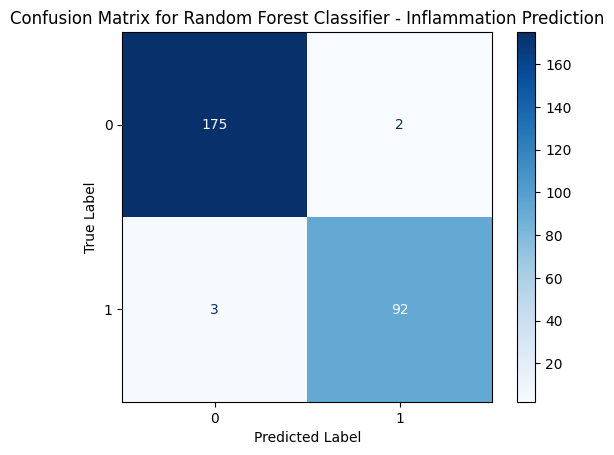

In [40]:
# Confusion Matrix for RFC
cm_rfc = confusion_matrix(y_test, y_pred_test_rfc)
disp_rfc = ConfusionMatrixDisplay(confusion_matrix=cm_rfc, display_labels=[0, 1]) # Assuming labels 0, 1

disp_rfc.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Random Forest Classifier - Inflammation Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

DNN model

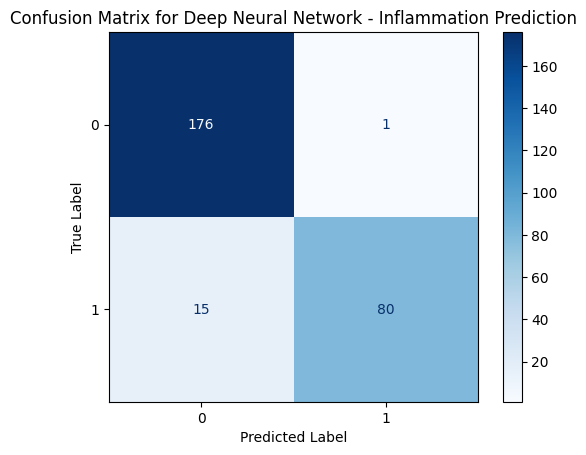

In [41]:
# Confusion Matrix for DNN
cm_dnn = confusion_matrix(y_test, y_pred_test_dnn)
disp_dnn = ConfusionMatrixDisplay(confusion_matrix=cm_dnn, display_labels=[0, 1]) # Assuming labels 0, 1

disp_dnn.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Deep Neural Network - Inflammation Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()